In [3]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
            df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

GaussianNB()

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [16]:
y_pred_lr = lr_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Logistic Regression Accuracy:", accuracy_lr)
print("Naive Bayes Accuracy:", accuracy_nb)
print("KNN Accuracy:", accuracy_knn)

Logistic Regression Accuracy: 0.9991397773954567
Naive Bayes Accuracy: 0.9764053228468101
KNN Accuracy: 0.9995435553526912


In [18]:
from sklearn.metrics import precision_score

precision_lr = precision_score(y_test, y_pred_lr)
precision_nb = precision_score(y_test, y_pred_nb)
precision_knn = precision_score(y_test, y_pred_knn)

print("Logistic Regression Precision:", precision_lr)
print("Naive Bayes Precision:", precision_nb)
print("KNN Precision:", precision_knn)

Logistic Regression Precision: 0.8266666666666667
Naive Bayes Precision: 0.058781869688385266
KNN Precision: 0.9186046511627907


In [19]:
from sklearn.metrics import recall_score

recall_lr = recall_score(y_test, y_pred_lr)
recall_nb = recall_score(y_test, y_pred_nb)
recall_knn = recall_score(y_test, y_pred_knn)

print("Logistic Regression Recall:", recall_lr)
print("Naive Bayes Recall:", recall_nb)
print("KNN Recall:", recall_knn)

Logistic Regression Recall: 0.6326530612244898
Naive Bayes Recall: 0.8469387755102041
KNN Recall: 0.8061224489795918


In [20]:
from sklearn.metrics import recall_score

recall_lr = recall_score(y_test, y_pred_lr)
recall_nb = recall_score(y_test, y_pred_nb)
recall_knn = recall_score(y_test, y_pred_knn)

print("Logistic Regression Recall:", recall_lr)
print("Naive Bayes Recall:", recall_nb)
print("KNN Recall:", recall_knn)

Logistic Regression Recall: 0.6326530612244898
Naive Bayes Recall: 0.8469387755102041
KNN Recall: 0.8061224489795918


In [21]:
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr)
f1_nb = f1_score(y_test, y_pred_nb)
f1_knn = f1_score(y_test, y_pred_knn)

print("Logistic Regression F1-score:", f1_lr)
print("Naive Bayes F1-score:", f1_nb)
print("KNN F1-score:", f1_knn)

Logistic Regression F1-score: 0.7167630057803468
Naive Bayes F1-score: 0.10993377483443709
KNN F1-score: 0.8586956521739131


In [22]:
from sklearn.metrics import roc_auc_score

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

roc_lr = roc_auc_score(y_test, y_prob_lr)
roc_nb = roc_auc_score(y_test, y_prob_nb)
roc_knn = roc_auc_score(y_test, y_prob_knn)

print("Logistic Regression ROC-AUC:", roc_lr)
print("Naive Bayes ROC-AUC:", roc_nb)
print("KNN ROC-AUC:", roc_knn)

Logistic Regression ROC-AUC: 0.9605494455801453
Naive Bayes ROC-AUC: 0.963247971529636
KNN ROC-AUC: 0.9437426067782205


In [23]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'KNN'],
    'Accuracy': [accuracy_lr, accuracy_nb, accuracy_knn],
    'Precision': [precision_lr, precision_nb, precision_knn],
    'Recall': [recall_lr, recall_nb, recall_knn],
    'F1-Score': [f1_lr, f1_nb, f1_knn],
    'ROC-AUC': [roc_lr, roc_nb, roc_knn]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.999140,0.826667,0.632653,0.716763,0.960549
1,Naive Bayes,0.976405,0.058782,0.846939,0.109934,0.963248
2,KNN,0.999544,0.918605,0.806122,0.858696,0.943743


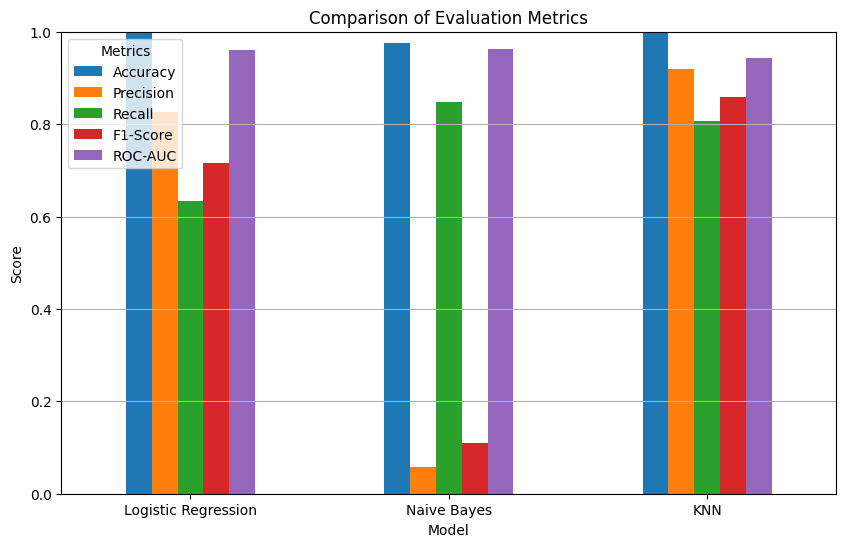

In [24]:
import matplotlib.pyplot as plt

results.set_index('Model').plot(kind='bar', figsize=(10, 6))

plt.title('Comparison of Evaluation Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(axis='y')

plt.show()

In [25]:
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    best_model = results.loc[results[metric].idxmax(), 'Model']
    best_score = results[metric].max()
    print(f"{metric}: {best_model} ({best_score:.4f})")

Accuracy: KNN (0.9995)
Precision: KNN (0.9186)
Recall: Naive Bayes (0.8469)
F1-Score: KNN (0.8587)
ROC-AUC: Naive Bayes (0.9632)


In [26]:
print("Logistic Regression ROC-AUC:", roc_lr)
print("Naive Bayes ROC-AUC:", roc_nb)
print("KNN ROC-AUC:", roc_knn)

Logistic Regression ROC-AUC: 0.9605494455801453
Naive Bayes ROC-AUC: 0.963247971529636
KNN ROC-AUC: 0.9437426067782205


In [27]:
print("Logistic Regression ROC-AUC:", roc_lr)
print("Naive Bayes ROC-AUC:", roc_nb)
print("KNN ROC-AUC:", roc_knn)

Logistic Regression ROC-AUC: 0.9605494455801453
Naive Bayes ROC-AUC: 0.963247971529636
KNN ROC-AUC: 0.9437426067782205


In [28]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Logistic Regression:")
print(cm_lr)

print("\nNaive Bayes:")
print(cm_nb)

print("\nKNN:")
print(cm_knn)

Logistic Regression:
[[56851    13]
 [   36    62]]

Naive Bayes:
[[55535  1329]
 [   15    83]]

KNN:
[[56857     7]
 [   19    79]]


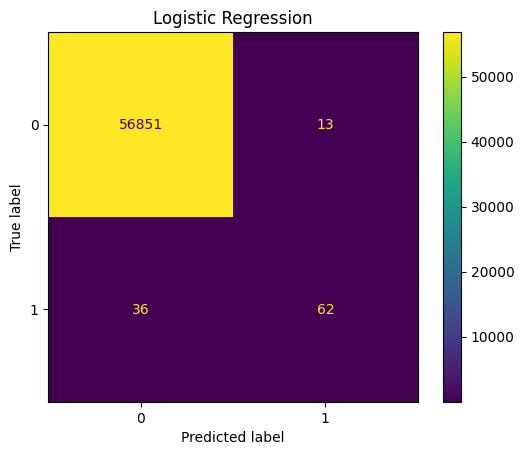

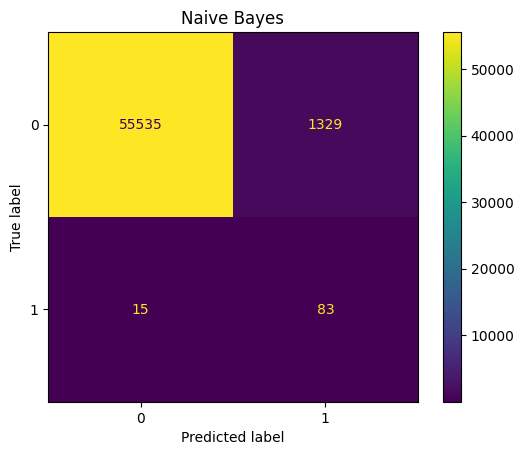

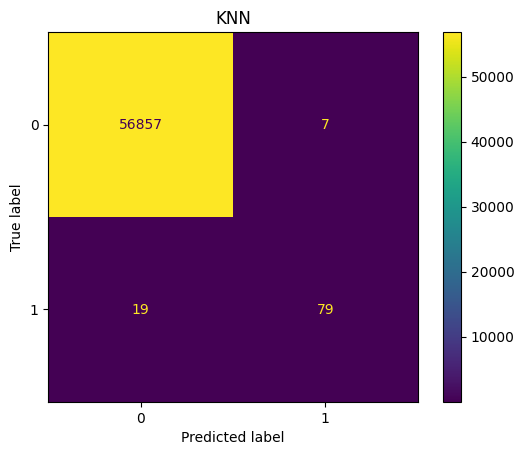

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naive Bayes")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN")
plt.show()

In [30]:
for name, cm in [
    ("Logistic Regression", cm_lr),
    ("Naive Bayes", cm_nb),
    ("KNN", cm_knn)
]:
    tn, fp, fn, tp = cm.ravel()

    print("\n", name)
    print("True Negatives :", tn)
    print("False Positives:", fp)
    print("False Negatives:", fn)
    print("True Positives :", tp)


 Logistic Regression
True Negatives : 56851
False Positives: 13
False Negatives: 36
True Positives : 62

 Naive Bayes
True Negatives : 55535
False Positives: 1329
False Negatives: 15
True Positives : 83

 KNN
True Negatives : 56857
False Positives: 7
False Negatives: 19
True Positives : 79


In [31]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'KNN'],
    'True Positives': [cm_lr[1,1], cm_nb[1,1], cm_knn[1,1]],
    'False Negatives': [cm_lr[1,0], cm_nb[1,0], cm_knn[1,0]],
    'False Positives': [cm_lr[0,1], cm_nb[0,1], cm_knn[0,1]]
})

comparison

,Model,True Positives,False Negatives,False Positives
0,Logistic Regression,62,36,13
1,Naive Bayes,83,15,1329
2,KNN,79,19,7


In [32]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9991,0.8267,0.6327,0.7168,0.9605
1,Naive Bayes,0.9764,0.0588,0.8469,0.1099,0.9632
2,KNN,0.9995,0.9186,0.8061,0.8587,0.9437


In [33]:
results['Average Score'] = results[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].mean(axis=1)

results[['Model', 'Average Score']]

,Model,Average Score
0,Logistic Regression,0.827154
1,Naive Bayes,0.591062
2,KNN,0.905342


In [34]:
ranking = results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].rank(ascending=False)

ranking

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,2.0,2.0,3.0,2.0,2.0
Naive Bayes,3.0,3.0,1.0,3.0,1.0
KNN,1.0,1.0,2.0,1.0,3.0


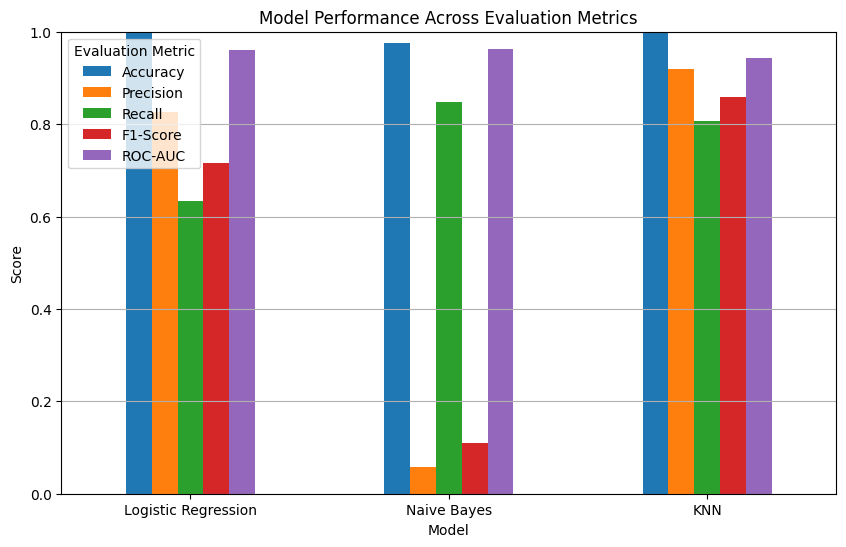

In [35]:
import matplotlib.pyplot as plt

results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].plot(kind='bar', figsize=(10, 6))

plt.title('Model Performance Across Evaluation Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(title='Evaluation Metric')

plt.show()